In the name of God

# **Machine Learning Homework: Clustering Analysis with K-Means and DBSCAN**


Seyed Mani Mirshabani
810801080

با توجه به اینکه قصد دارم در گیتهابم قرار بدم و بعدا به عنوان رزومه باشه با اجازه شما متن های نوتبوک رو به انگلیسی مینویسم (برای این کار از هوش مصنوعی استفاده نمیکنم و هرچیزی که متوجه شده باشم رو خودم به انگلیسی مینویسم برای همین پیشاپیش بابت اشتباهات مربوط به انگلیسی معذرت میخوام)

## **Part 1: Manual Clustering Calculations**  

### **Step 1: K-Means Clustering (2D Data)**  

Given the following 2D data points:

| Point | x1 | x2 |
|-------|----|----|
| A     | 1  | 2  |
| B     | 1  | 4  |
| C     | 3  | 2  |
| D     | 5  | 8  |
| E     | 6  | 9  |

#### Tasks:
- Initialize centroids at A and D.
- Assign each point to the nearest centroid.
- Compute new centroids.
- Repeat assignment and update steps for 2 iterations.
- Plot the final clusters manually.


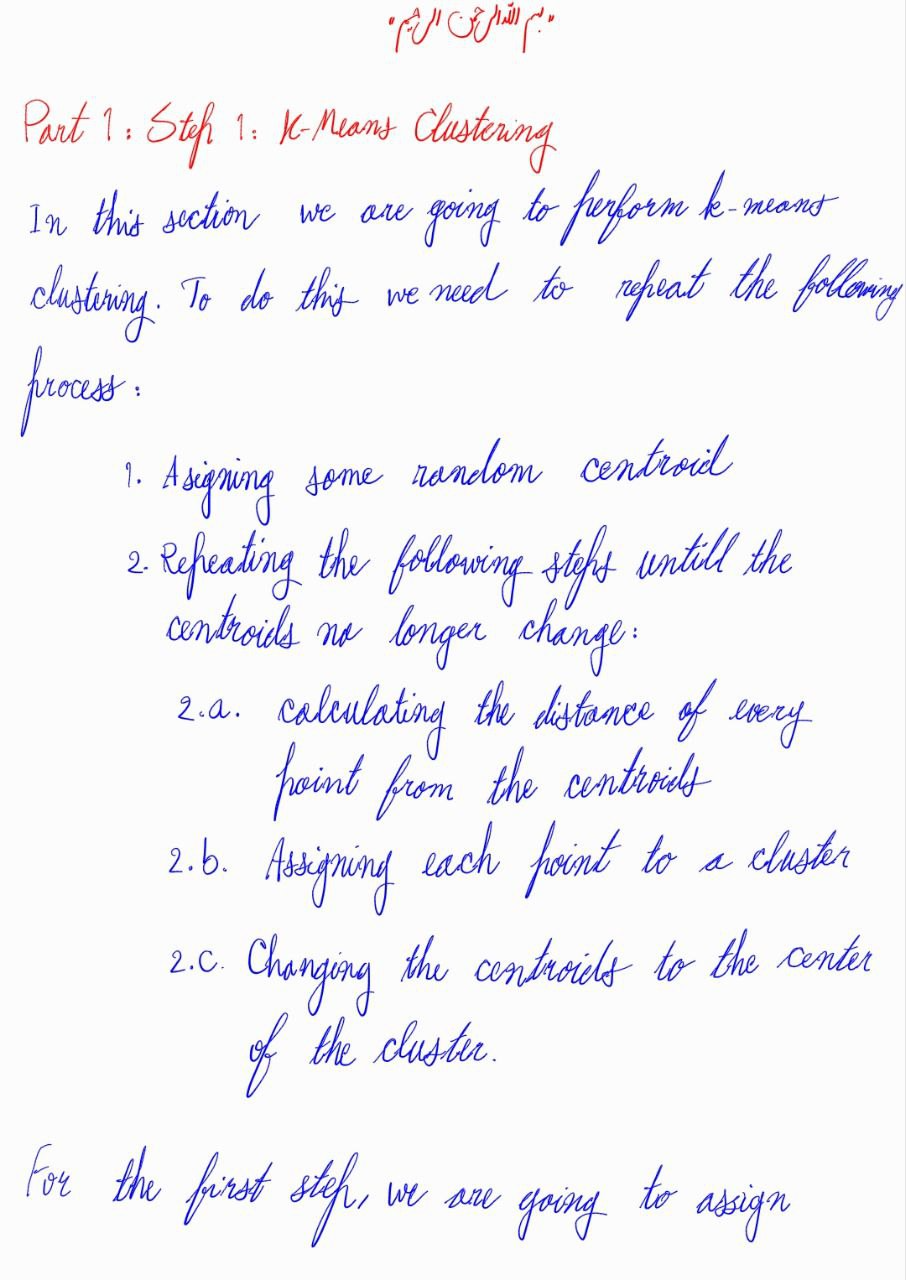

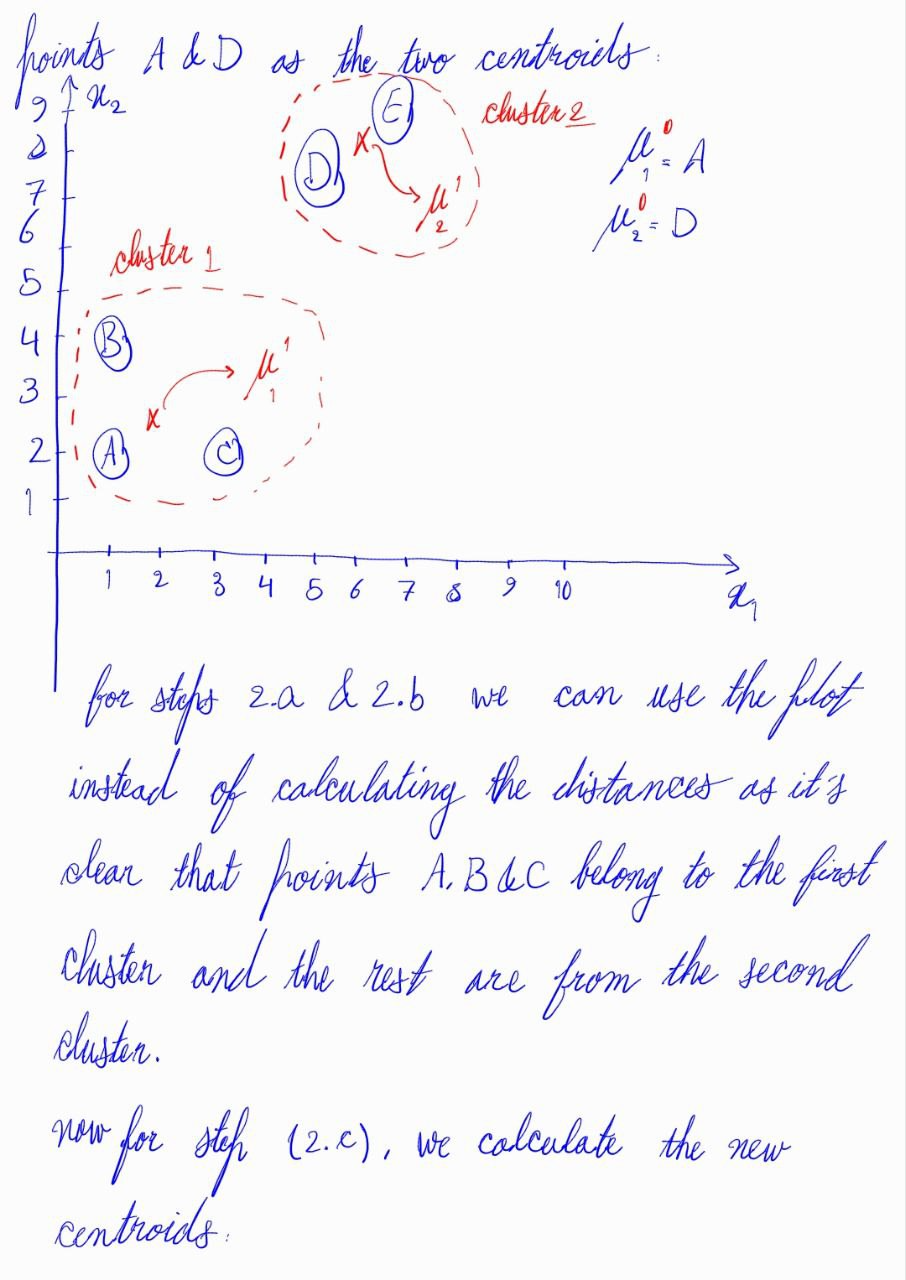

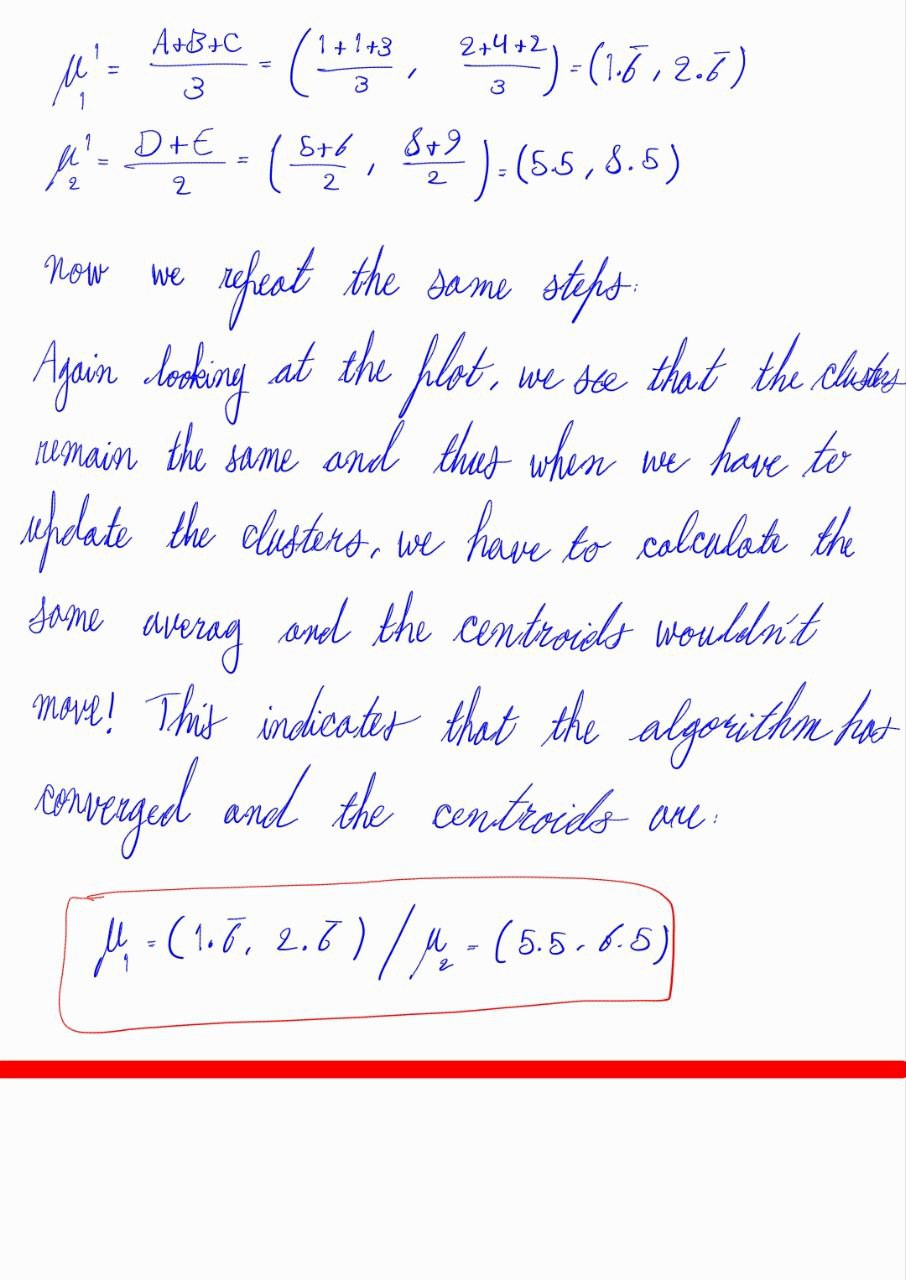

### **Step 2: Silhouette Score (Manual)**  

Using the final clusters from Step 1:
- Compute intra-cluster distance `a(i)` for point C.
- Compute nearest-cluster distance `b(i)` for point C.
- Calculate silhouette score `s(i) = (b(i) - a(i)) / max(a(i), b(i))`.
- Interpret the score.


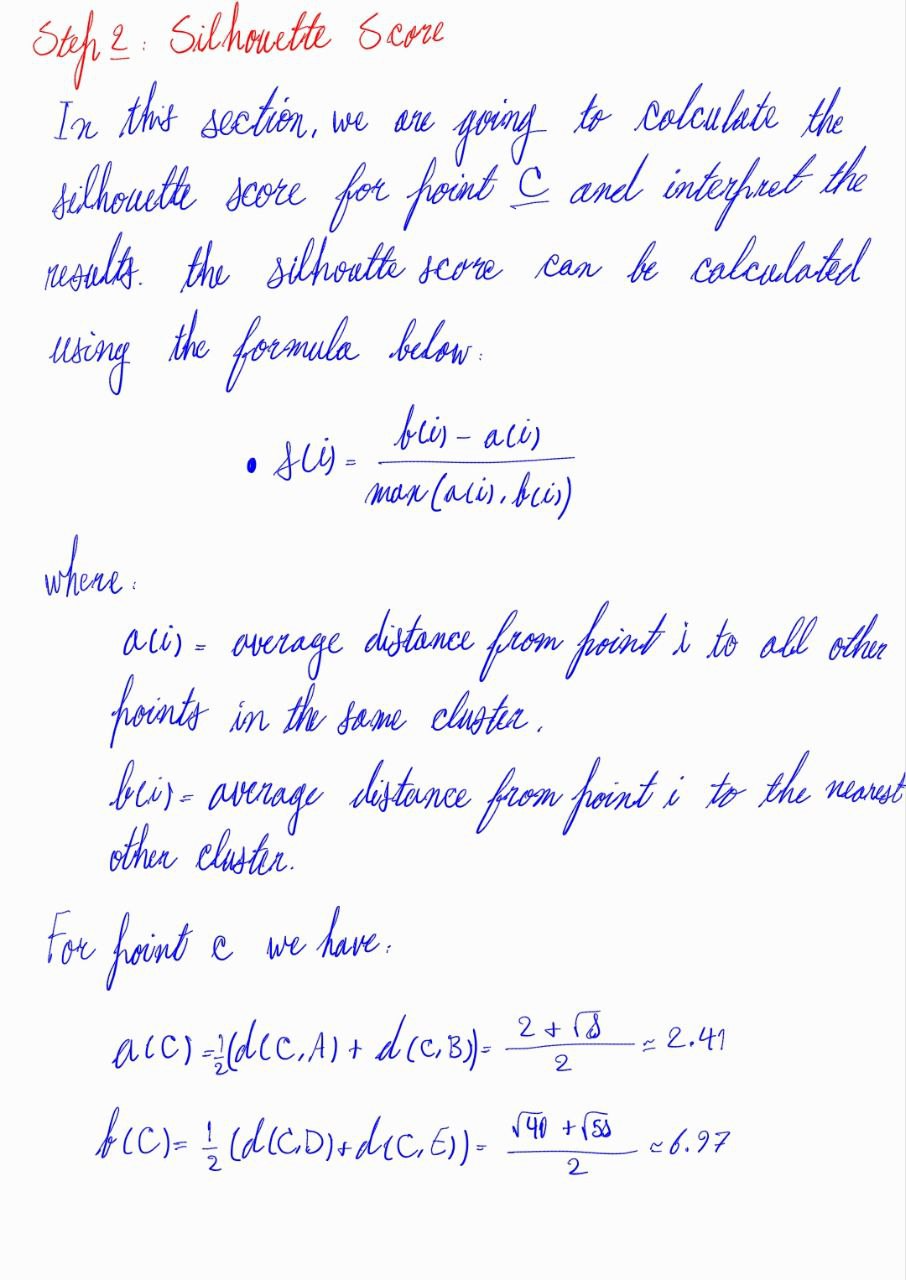

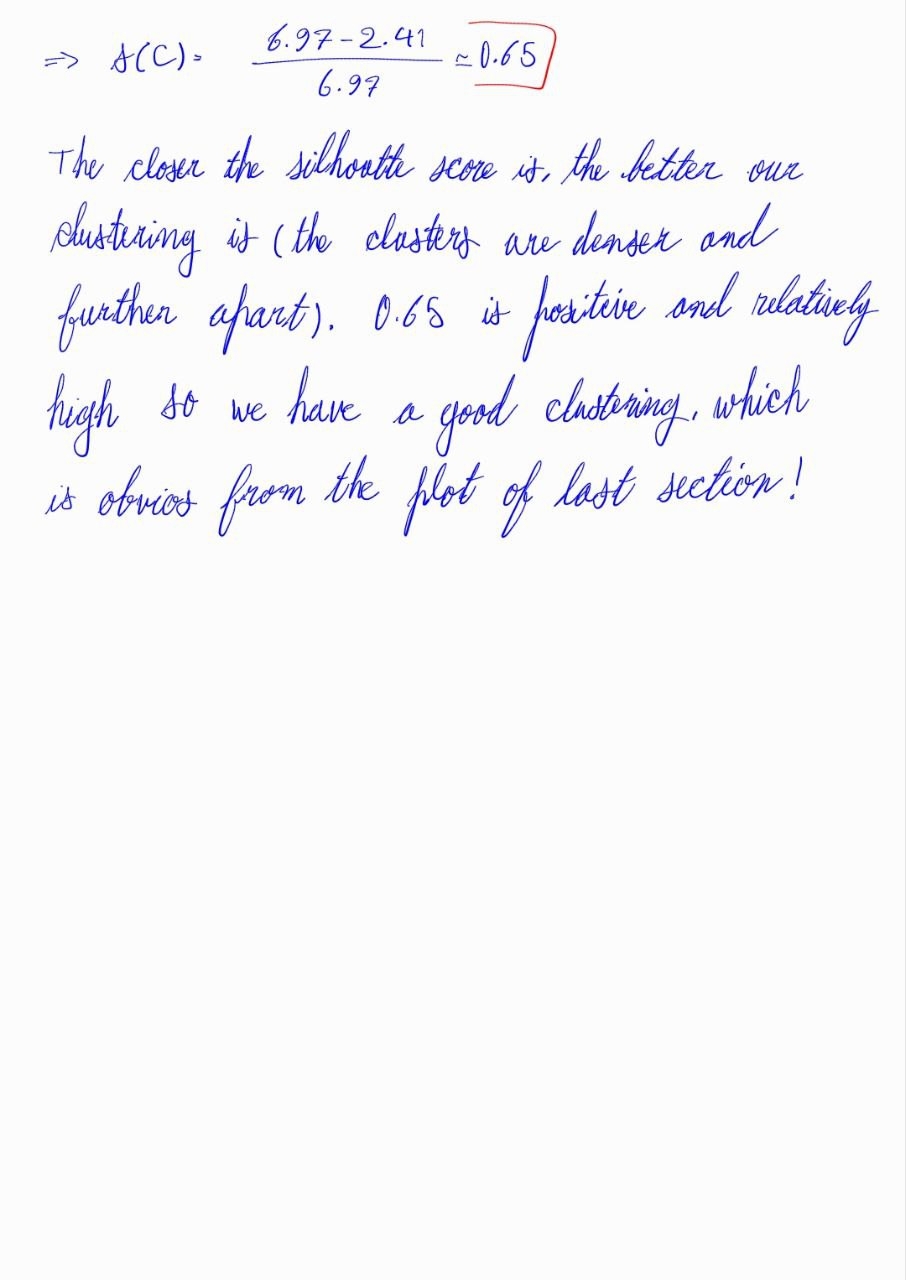

## **Part 2: Python Implementation of Clustering Algorithms**  

### **Step 1: Load Dataset and Visualize**  


- Use synthetic data from `make_blobs`.
- Plot the raw data.


In this section we are going to create our data (which consist of three blobs! with a std of 1 and has 100 samples)

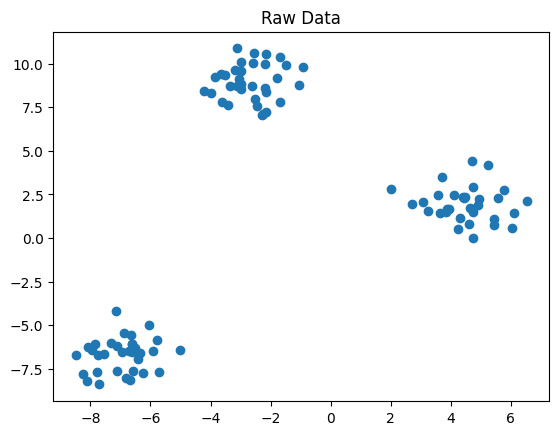

In [ ]:
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt

X, _ = make_blobs(n_samples=100, centers=3, cluster_std=1.0, random_state=42)
plt.scatter(X[:, 0], X[:, 1])
plt.title("Raw Data")
plt.show()

Looking at the data we can clearly see that there are 3 distinct cluster and the k-means algorithm should be able to detect them easily.

### **Step 2: K-Means Clustering**  

- Apply `KMeans(n_clusters=3)`.
- Plot clustered data.
- Compute silhouette score.

In this section we are going to apply the k means algorithm. To simulate a real situation, we are not going to use the code given, instead we are going to assume we don't know the data and use the elbow method (ans silhouette score) to find the number of clusters.

Then we will use this number to make the final k-means and evaluate its performance using the silhouette score and plot as well as a scatter plot showing the result of the clustering.

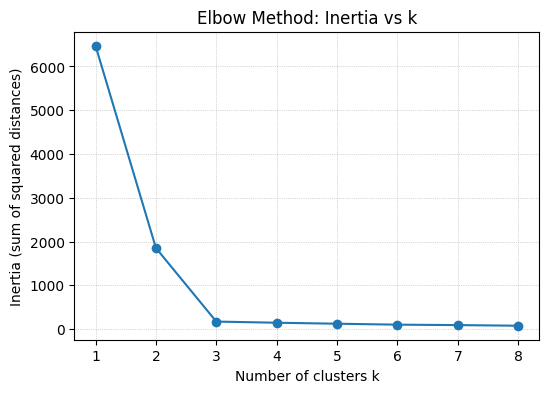

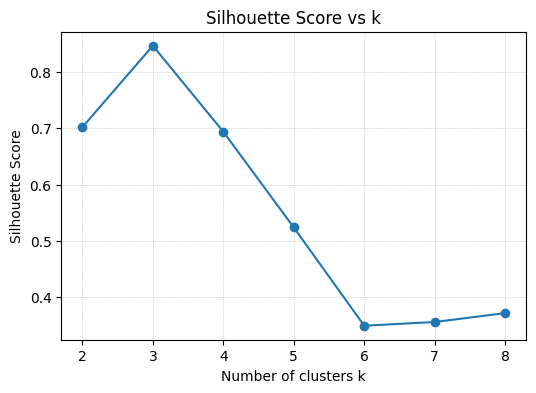

Automatically chosen k (highest silhouette): 3  (silhouette = 0.8470)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples

ks = list(range(1, 9))
inertias = []
for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X)
    inertias.append(km.inertia_)

plt.figure(figsize=(6,4))
plt.plot(ks, inertias, marker='o')
plt.xticks(ks)
plt.xlabel("Number of clusters k")
plt.ylabel("Inertia (sum of squared distances)")
plt.title("Elbow Method: Inertia vs k")
plt.grid(True, linestyle=':', linewidth=0.5)
plt.show()

ks_s = list(range(2, 9))
sil_scores = []
for k in ks_s:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    sil_scores.append(silhouette_score(X, labels))

plt.figure(figsize=(6,4))
plt.plot(ks_s, sil_scores, marker='o')
plt.xticks(ks_s)
plt.xlabel("Number of clusters k")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs k")
plt.grid(True, linestyle=':', linewidth=0.5)
plt.show()

best_k = ks_s[int(np.argmax(sil_scores))]
print(f"Automatically chosen k (highest silhouette): {best_k}  (silhouette = {max(sil_scores):.4f})")


Looking at the elbow method plot, we can clearly see that we should set k to 3, which is validated by the "Silhouette score vs k" plot.

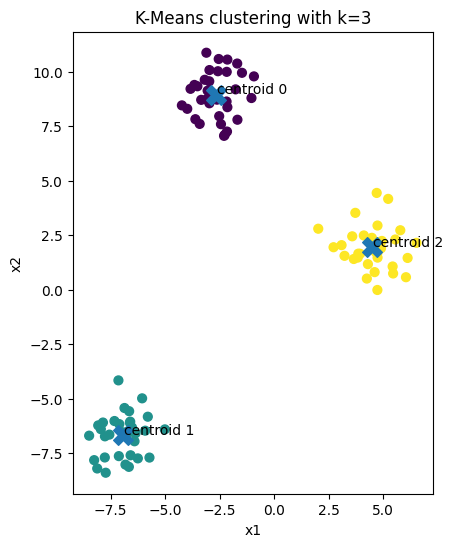

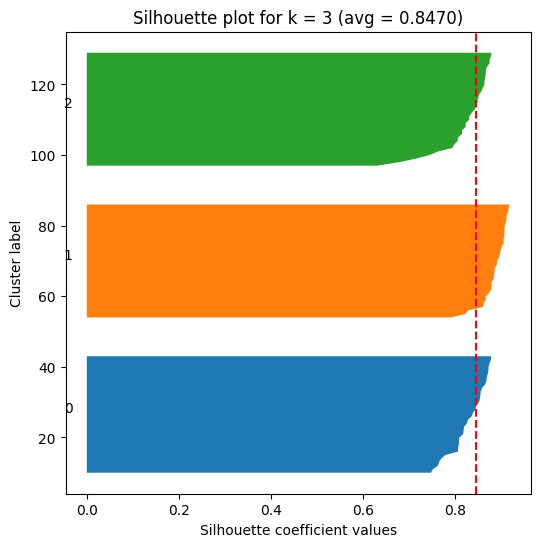

Final silhouette score for k=3: 0.8470


In [ ]:
kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
labels_final = kmeans_final.fit_predict(X)
centers = kmeans_final.cluster_centers_

plt.figure(figsize=(6,6))
plt.scatter(X[:,0], X[:,1], c=labels_final, s=40)
plt.scatter(centers[:,0], centers[:,1], marker='X', s=200)
for i, c in enumerate(centers):
    plt.text(c[0]+0.05, c[1]+0.05, f"centroid {i}")
plt.title(f"K-Means clustering with k={best_k}")
plt.xlabel("x1")
plt.ylabel("x2")
plt.gca().set_aspect('equal', adjustable='box')
plt.show()

sample_silhouette_values = silhouette_samples(X, labels_final)
avg_sil = silhouette_score(X, labels_final)

y_lower = 10
plt.figure(figsize=(6,6))
for i in range(best_k):
    ith_vals = sample_silhouette_values[labels_final == i]
    ith_vals.sort()
    size_i = ith_vals.shape[0]
    y_upper = y_lower + size_i
    plt.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_vals)
    plt.text(-0.05, y_lower + 0.5 * size_i, str(i))
    y_lower = y_upper + 10  # gap between clusters

plt.xlabel("Silhouette coefficient values")
plt.ylabel("Cluster label")
plt.title(f"Silhouette plot for k = {best_k} (avg = {avg_sil:.4f})")
plt.axvline(x=avg_sil, color="red", linestyle="--")
plt.show()

print(f"Final silhouette score for k={best_k}: {avg_sil:.4f}")

And after setting k to 3 and looking at the results we can see that the model has performed a perfect clustering and got a very high silhouette score of 0.85!

### **Step 3: Hierarchical Clustering**  

- Use `AgglomerativeClustering(n_clusters=3)`.
- Plot results.


Now we will perform a hierarchical clustering

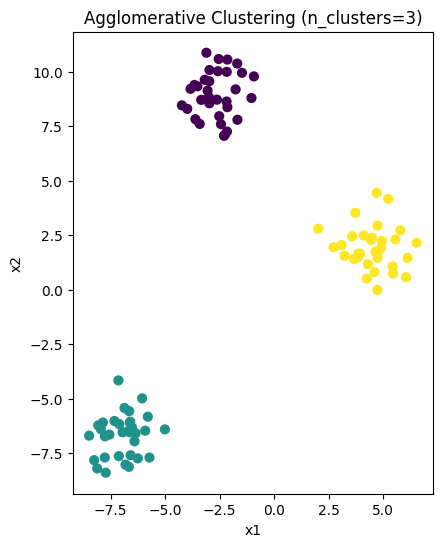

In [ ]:
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt

agg = AgglomerativeClustering(n_clusters=3)
labels_agg = agg.fit_predict(X)

plt.figure(figsize=(6,6))
plt.scatter(X[:,0], X[:,1], c=labels_agg, s=40)
plt.title("Agglomerative Clustering (n_clusters=3)")
plt.xlabel("x1")
plt.ylabel("x2")
plt.gca().set_aspect('equal', adjustable='box')
plt.show()

Using the knowledge from the last section we set the number of clusters to 3 and visualised the results. As we can see we got a perfect score just like with k-means.

Next let's draw the silhouette plot and calculate the average score.

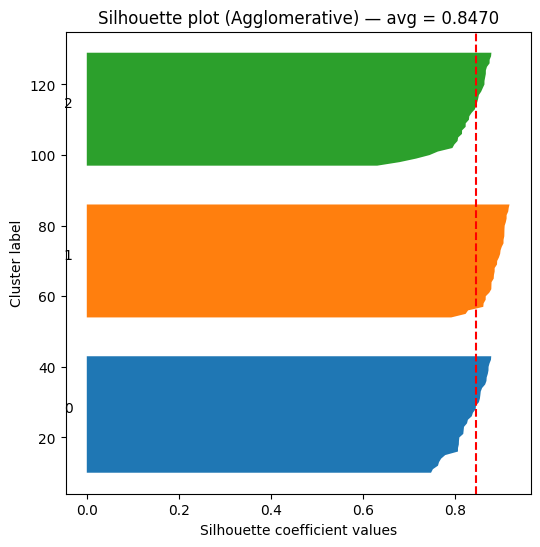

Agglomerative clustering average silhouette score: 0.8470


In [ ]:
from sklearn.metrics import silhouette_score, silhouette_samples
import numpy as np
import matplotlib.pyplot as plt

sil_avg_agg = silhouette_score(X, labels_agg)
sample_silhouette_values = silhouette_samples(X, labels_agg)

plt.figure(figsize=(6,6))
y_lower = 10
n_clusters = len(np.unique(labels_agg))
for i in range(n_clusters):
    ith_vals = sample_silhouette_values[labels_agg == i]
    ith_vals.sort()
    size_i = ith_vals.shape[0]
    y_upper = y_lower + size_i
    plt.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_vals)
    plt.text(-0.05, y_lower + 0.5 * size_i, str(i))
    y_lower = y_upper + 10  # gap between clusters

plt.xlabel("Silhouette coefficient values")
plt.ylabel("Cluster label")
plt.title(f"Silhouette plot (Agglomerative) — avg = {sil_avg_agg:.4f}")
plt.axvline(x=sil_avg_agg, color="red", linestyle="--")
plt.show()

print(f"Agglomerative clustering average silhouette score: {sil_avg_agg:.4f}")

Given the fact that the clustering result is identical to k-means, we got the exact same plot and average score :)

Which shows that the clustering had a good result.

Up next we will draw the dendrogram of the clusters to get an overall idea of how the data was merged (it doesn't add any value in our case but it looks good :) )

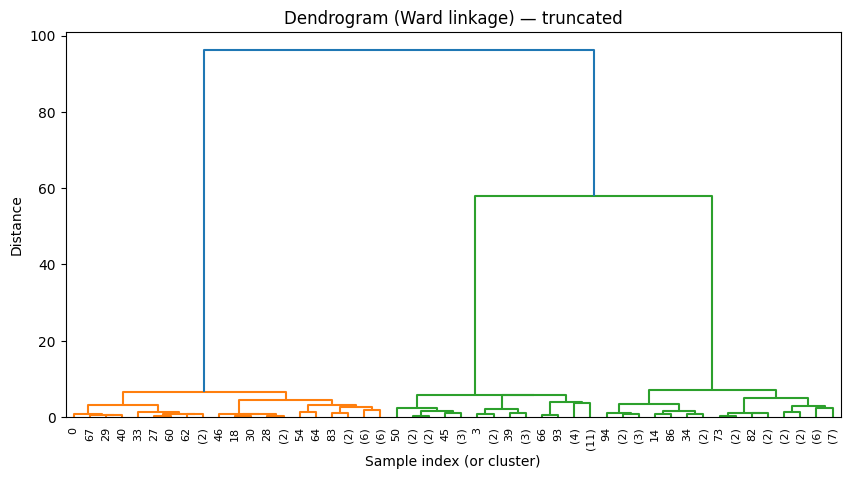

In [ ]:
import scipy.cluster.hierarchy as sch
import matplotlib.pyplot as plt

linked = sch.linkage(X, method='ward')

plt.figure(figsize=(10,5))
sch.dendrogram(linked, truncate_mode='level', p=5)
plt.title("Dendrogram (Ward linkage) — truncated")
plt.xlabel("Sample index (or cluster)")
plt.ylabel("Distance")
plt.show()

### **Step 4: DBSCAN Clustering**  

- Apply `DBSCAN(eps=0.8, min_samples=5)`.
- Plot clusters and noise.

Here again we change the code given to make it look a little better when drawing the plot.

DBSCAN (eps=0.8, min_samples=5) -> clusters (excluding noise): 3, noise points: 19
Label counts: {np.int64(-1): np.int64(19), np.int64(0): np.int64(29), np.int64(1): np.int64(30), np.int64(2): np.int64(22)}


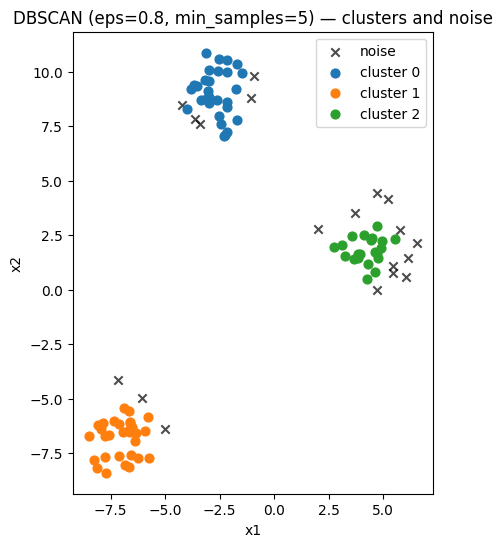

Silhouette score (computed on non-noise points): 0.8735


In [ ]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

db = DBSCAN(eps=0.8, min_samples=5)
labels_db = db.fit_predict(X)
core_mask = np.zeros_like(labels_db, dtype=bool)
if hasattr(db, "core_sample_indices_"):
    core_mask[db.core_sample_indices_] = True

unique_labels, counts = np.unique(labels_db, return_counts=True)
n_clusters = len(unique_labels) - (1 if -1 in unique_labels else 0)
n_noise = int((labels_db == -1).sum())
print(f"DBSCAN (eps=0.8, min_samples=5) -> clusters (excluding noise): {n_clusters}, noise points: {n_noise}")
print("Label counts:", dict(zip(unique_labels, counts)))

plt.figure(figsize=(6,6))
colors = cm.tab10(np.linspace(0,1,10))
for lab in unique_labels:
    mask = labels_db == lab
    if lab == -1:
        plt.scatter(X[mask,0], X[mask,1], c='k', marker='x', label='noise', alpha=0.7)
    else:
        plt.scatter(X[mask,0], X[mask,1], color=colors[lab % 10], label=f"cluster {lab}", s=40)
plt.legend(loc='best')
plt.title("DBSCAN (eps=0.8, min_samples=5) — clusters and noise")
plt.xlabel("x1"); plt.ylabel("x2")
plt.gca().set_aspect('equal', adjustable='box')
plt.show()

mask_non_noise = labels_db != -1
sil_non_noise = silhouette_score(X[mask_non_noise], labels_db[mask_non_noise])
print(f"Silhouette score (computed on non-noise points): {sil_non_noise:.4f}")

This is the first algorithm where we see that the clustering hasn't been perfect, even though the Silhouette score is hight. This is because DBSCAN has marked quite a few of the points as noise data.

DBSCAN is one of the clustering algorithms that requires lots of parameter tuning, so in the next section we will try different parameters to see if we can improve the performance or not.

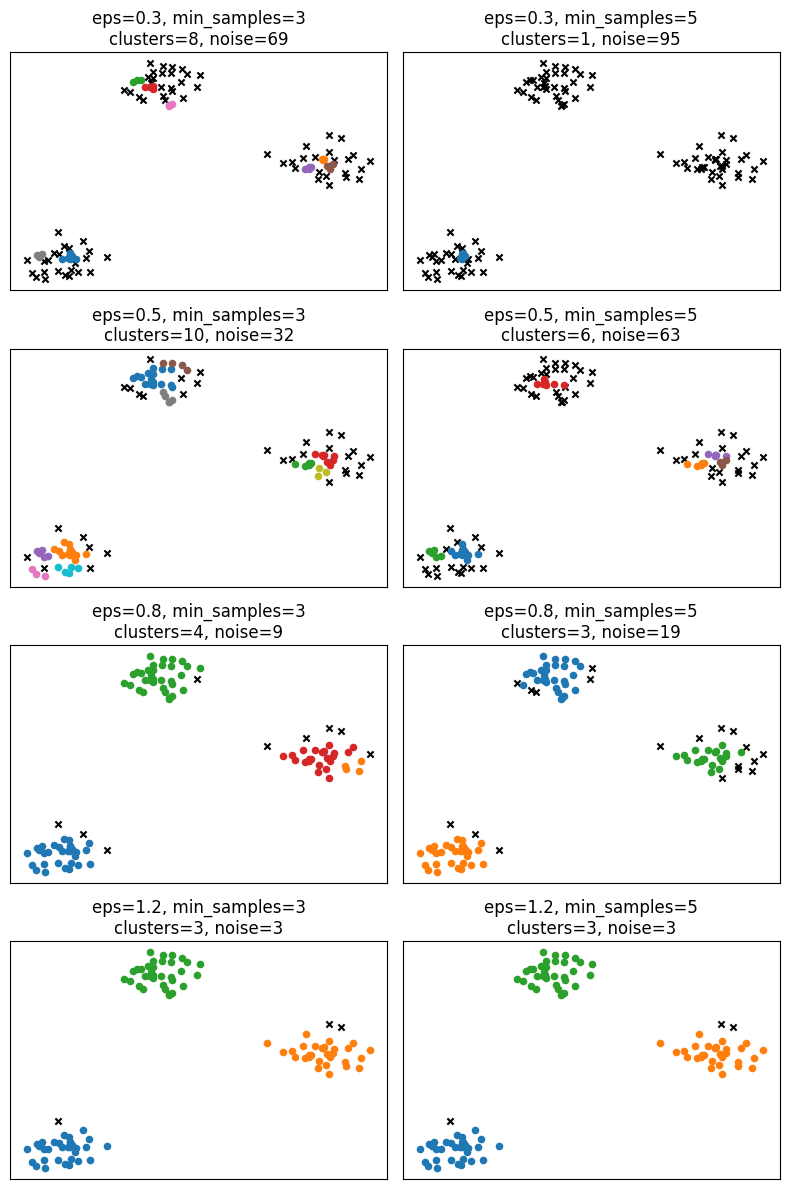

Summary (eps, min_samples, n_clusters, n_noise, silhouette_on_non_noise):
(0.3, 3, 8, 69, np.float64(0.7462172524920369))
(0.3, 5, 1, 95, None)
(0.5, 3, 10, 32, np.float64(0.46508972863368625))
(0.5, 5, 6, 63, np.float64(0.644061147469864))
(0.8, 3, 4, 9, np.float64(0.70206252992811))
(0.8, 5, 3, 19, np.float64(0.8734750488392514))
(1.2, 3, 3, 3, np.float64(0.8538267045219459))
(1.2, 5, 3, 3, np.float64(0.8538267045219459))


In [ ]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

eps_list = [0.3, 0.5, 0.8, 1.2]
min_samples_list = [3, 5]
nrows = len(eps_list)
ncols = len(min_samples_list)

plt.figure(figsize=(4*ncols, 3*nrows))
colors = cm.tab10(np.linspace(0,1,10))

results = []

for i, eps in enumerate(eps_list):
    for j, ms in enumerate(min_samples_list):
        ax = plt.subplot(nrows, ncols, i*ncols + j + 1)
        db = DBSCAN(eps=eps, min_samples=ms)
        labs = db.fit_predict(X)
        unique, counts = np.unique(labs, return_counts=True)
        n_clusters = len(unique) - (1 if -1 in unique else 0)
        n_noise = int((labs == -1).sum())
        # scatter
        for lab in unique:
            mask = labs == lab
            if lab == -1:
                ax.scatter(X[mask,0], X[mask,1], c='k', marker='x', s=20)
            else:
                ax.scatter(X[mask,0], X[mask,1], color=colors[lab % 10], s=20)
        ax.set_title(f"eps={eps}, min_samples={ms}\nclusters={n_clusters}, noise={n_noise}")
        ax.set_xticks([]); ax.set_yticks([])
        sil = None
        if n_clusters >= 2:
            mask_nn = labs != -1
            try:
                sil = silhouette_score(X[mask_nn], labs[mask_nn])
            except Exception:
                sil = None
        results.append((eps, ms, n_clusters, n_noise, sil))

plt.tight_layout()
plt.show()

print("Summary (eps, min_samples, n_clusters, n_noise, silhouette_on_non_noise):")
for row in results:
    print(row)

The best results where achieved with eps=1.2 and min_samples=5 (bottom right plot) but even after some hyperparameter tuning, we can still see that 3 points were detected as noise points and the score isn't as hight as it can be.

Next let's draw the per-cluster average silhouette score (for some verity instead of just repeating the same plot for all the algorithms :) )

Counts per label (including -1 for noise): {np.int64(-1): np.int64(19), np.int64(0): np.int64(29), np.int64(1): np.int64(30), np.int64(2): np.int64(22)}


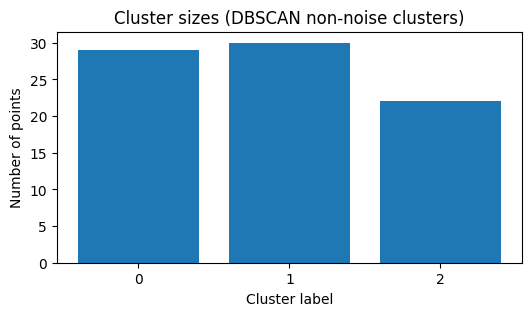

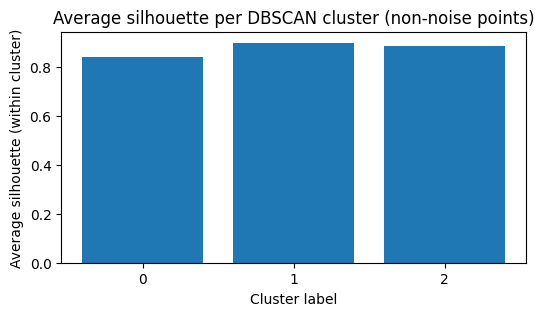

Per-cluster average silhouette: {np.int64(0): 0.8390311291122499, np.int64(1): 0.8980069457544174, np.int64(2): 0.8854258108677994}


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_samples

unique, counts = np.unique(labels_db, return_counts=True)
cluster_info = dict(zip(unique, counts))
print("Counts per label (including -1 for noise):", cluster_info)

clusters = [lab for lab in unique if lab != -1]
sizes = [cluster_info[lab] for lab in clusters]

plt.figure(figsize=(6,3))
plt.bar([str(c) for c in clusters], sizes)
plt.xlabel("Cluster label")
plt.ylabel("Number of points")
plt.title("Cluster sizes (DBSCAN non-noise clusters)")
plt.show()

if len(clusters) >= 2:
    mask_non_noise = labels_db != -1
    sil_vals = silhouette_samples(X[mask_non_noise], labels_db[mask_non_noise])
    labels_non_noise = labels_db[mask_non_noise]
    cluster_avg_sil = {}
    for c in clusters:
        cluster_avg_sil[c] = float(sil_vals[labels_non_noise == c].mean())
    plt.figure(figsize=(6,3))
    plt.bar([str(c) for c in clusters], [cluster_avg_sil[c] for c in clusters])
    plt.xlabel("Cluster label")
    plt.ylabel("Average silhouette (within cluster)")
    plt.title("Average silhouette per DBSCAN cluster (non-noise points)")
    plt.show()
    print("Per-cluster average silhouette:", cluster_avg_sil)
else:
    print("Per-cluster silhouette not computed (need >=2 non-noise clusters).")

### **Step 5: Comparison**  

As the last step, we will compare the 3 models.

KMeans silhouette: 0.8469881221532085
Agglomerative silhouette: 0.8469881221532085
ARI between KMeans and DBSCAN: 0.7168
ARI between Agglomerative and DBSCAN: 0.7168


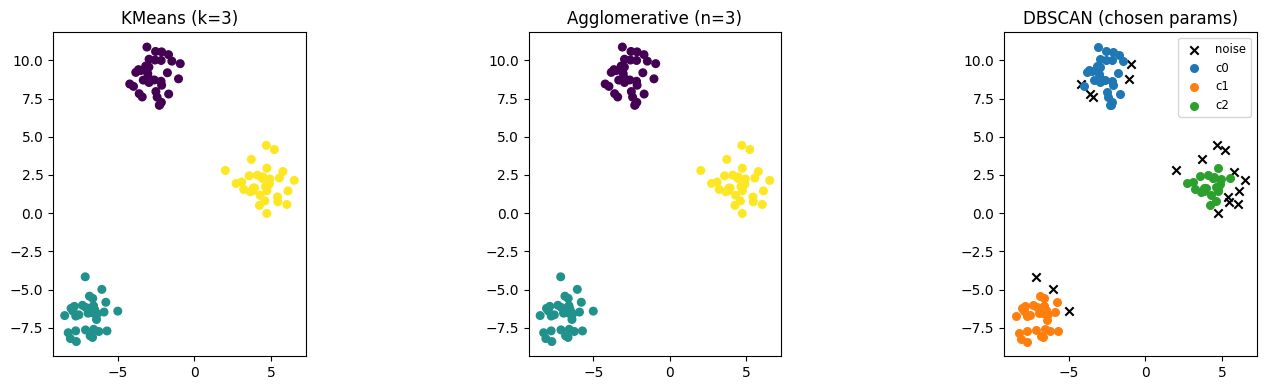

In [ ]:
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import adjusted_rand_score, silhouette_score
import matplotlib.pyplot as plt

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_km = kmeans.fit_predict(X)

agg = AgglomerativeClustering(n_clusters=3)
labels_agg = agg.fit_predict(X)

labels_db_for_eval = labels_db

print("KMeans silhouette:", silhouette_score(X, labels_km))
print("Agglomerative silhouette:", silhouette_score(X, labels_agg))
ari_km_db = adjusted_rand_score(labels_km, labels_db_for_eval)
ari_agg_db = adjusted_rand_score(labels_agg, labels_db_for_eval)
print(f"ARI between KMeans and DBSCAN: {ari_km_db:.4f}")
print(f"ARI between Agglomerative and DBSCAN: {ari_agg_db:.4f}")

plt.figure(figsize=(15,4))
plt.subplot(1,3,1)
plt.scatter(X[:,0], X[:,1], c=labels_km, s=30)
plt.title("KMeans (k=3)")
plt.gca().set_aspect('equal', adjustable='box')

plt.subplot(1,3,2)
plt.scatter(X[:,0], X[:,1], c=labels_agg, s=30)
plt.title("Agglomerative (n=3)")
plt.gca().set_aspect('equal', adjustable='box')

plt.subplot(1,3,3)
unique = np.unique(labels_db_for_eval)
colors = cm.tab10(np.linspace(0,1,10))
for lab in unique:
    mask = labels_db_for_eval == lab
    if lab == -1:
        plt.scatter(X[mask,0], X[mask,1], c='k', marker='x', label='noise')
    else:
        plt.scatter(X[mask,0], X[mask,1], color=colors[lab % 10], s=30, label=f"c{lab}")
plt.title("DBSCAN (chosen params)")
plt.legend(loc='best', fontsize='small')
plt.gca().set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.show()

As we can see from the plots, KMeans and Agglomerative methods have detected the clusters almost perfectly while DBSCAN (with the default settings given) has some difficulties and labeled quite a few of the points as noise. This is to be expected because our data was divided into clusters based on the distance between the data points (and not the density) which makes it and ideal case for algorithms like K-Means that rely on distance or heirchical methods that merge the clusters based on distance while DBSACN looks at the density of the data and thus is likely to detect points that are in the less concentrated areas of each cluster as noise.